In [22]:
from slepc4py import SLEPc
from ufl import dx, grad, curl, div, inner, TrialFunction, TestFunction, cross
import numpy as np
from dolfinx.fem import (dirichletbc, Function, functionspace, form,
                         locate_dofs_topological)
from mpi4py import MPI
from dolfinx.fem.petsc import assemble_matrix
from petsc4py import PETSc
from dolfinx.mesh import (create_box, locate_entities_boundary,
                          CellType, GhostMode, exterior_facet_indices)
import sys

def par_print(string):
    if comm.rank == 0:
        print(string)
        sys.stdout.flush()



# Eigenvalue computation

In [2]:
def eigenvalues(n_eigs, shift, V, bcs):
    # Define problem
    u, v = TrialFunction(V), TestFunction(V)
    a = form(inner(curl(u), curl(v)) * dx)
    b = form(inner(u, v) * dx)

    # Assemble matrices
    A = assemble_matrix(a, bcs, diagonal=1.0)
    A.assemble()
    # Zero rows of boundary DOFs of B. See [1]
    B = assemble_matrix(b, bcs, diagonal=0.0)
    B.assemble()

    # Create SLEPc Eigenvalue solver
    eps = SLEPc.EPS().create(comm)
    eps.setOperators(A, B)
    eps.setType(SLEPc.EPS.Type.KRYLOVSCHUR)
    eps.setProblemType(SLEPc.EPS.ProblemType.GHEP)
    eps.setWhichEigenpairs(eps.Which.TARGET_MAGNITUDE)
    eps.setTarget(shift)

    st = eps.getST()
    st.setType(SLEPc.ST.Type.SINVERT)
    st.setShift(shift)

    eps.setDimensions(n_eigs, PETSc.DECIDE, PETSc.DECIDE)
    eps.setFromOptions()
    eps.solve()

    its = eps.getIterationNumber()
    eps_type = eps.getType()
    n_ev, n_cv, mpd = eps.getDimensions()
    tol, max_it = eps.getTolerances()
    n_conv = eps.getConverged()

    par_print(f"Number of iterations: {its}")
    par_print(f"Solution method: {eps_type}")
    par_print(f"Number of requested eigenvalues: {n_ev}")
    par_print(f"Stopping condition: tol={tol}, maxit={max_it}")
    par_print(f"Number of converged eigenpairs: {n_conv}")

    computed_eigenvalues = []
    for i in range(min(n_conv, n_eigs)):
        lmbda = eps.getEigenvalue(i)
        computed_eigenvalues.append(np.round(np.real(lmbda), 1))

    eps.destroy()
    return np.sort(computed_eigenvalues)


def boundary(x):
    "Boundary marker"
    return boundary_lr(x) | boundary_tb(x) | boundary_fb(x)


def boundary_lr(x):
    "Left and right boundary marker"
    return np.isclose(x[0], 0.0) | np.isclose(x[0], np.pi)

def boundary_fb(x):
    "Front and back boundary marker"
    return np.isclose(x[1], 0.0) | np.isclose(x[1], np.pi)

def boundary_tb(x):
    "Top and bottom boundary marker"
    return np.isclose(x[2], 0.0) | np.isclose(x[2], np.pi)


def print_eigenvalues(mesh):
    # Nédélec
    V_n = functionspace(mesh, ("N1curl", 1))
    # Set boundary DOFs to 0 (u x n = 0 on \partial \Omega).

    # Version 1 utilizing "boundary" function
    # ud_n = Function(V_n)
    # f_dim = mesh.topology.dim - 1
    # boundary_facets = locate_entities_boundary(mesh, f_dim, boundary)
    # boundary_dofs_n = locate_dofs_topological(
    #     V_n, f_dim, boundary_facets)
    # bcs_nedelec = [dirichletbc(ud_n, boundary_dofs_n)]

    # Version 2 utilizing exterior_facet_indices
    bc_facets = exterior_facet_indices(mesh.topology)
    bc_dofs = locate_dofs_topological(V_n, mesh.topology.dim - 1, bc_facets)
    u_bc = Function(V_n)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_nedelec = [dirichletbc(u_bc, bc_dofs)]


    # Solve Maxwell eigenvalue problem
    eigenvalues_nedelec = eigenvalues(n_eigs, shift, V_n, bcs_nedelec)

    # Print results
    np.set_printoptions(formatter={'float': '{:5.1f}'.format})
    eigenvalues_exact = np.array([2.0, 2.0, 2.0, 3.0, 3.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0])
    par_print(f"Exact    = {eigenvalues_exact}")
    par_print(f"Nédélec  = {eigenvalues_nedelec}")
    # par_print(f"Lagrange = {eigenvalues_lagrange}")

In [7]:
# Number of elements in each direction
n = 20
# Number of eigenvalues to compute
n_eigs = 12
# Find eigenvalues near
shift = 2.5
# Domain corners
corners = ((0.0, 0.0, 0.0), (np.pi, np.pi, np.pi))

comm = MPI.COMM_WORLD

par_print("Right diagonal mesh:")
mesh = create_box(
    comm,
    corners, (n, n, n),
    CellType.tetrahedron,
    ghost_mode=GhostMode.none)
mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)
print_eigenvalues(mesh)

# par_print("\nCrossed diagonal mesh:")
# mesh = create_box(
#     comm,
#     corners, (n, n, n),
#     CellType.tetrahedron,
#     ghost_mode=GhostMode.none,
#     diagonal=DiagonalType.crossed)
# print_eigenvalues(mesh)

Right diagonal mesh:
Number of iterations: 4
Solution method: krylovschur
Number of requested eigenvalues: 12
Stopping condition: tol=1e-08, maxit=4419
Number of converged eigenpairs: 16
Exact    = [  2.0   2.0   2.0   3.0   3.0   5.0   5.0   5.0   5.0   5.0   5.0]
Nédélec  = [  0.0   0.0  -0.0   2.0   2.0   2.0   3.0   3.0   5.0   5.0   5.0   5.0]


# Eigenvalue computation 3field

In [19]:
from dolfinx.fem.petsc import assemble_matrix_nest
def eigenvalues(n_eigs, shift, V1, V2, V3, bcs):
    # # Define trial and test functions
    # (w, u, p) = TrialFunction(V1), TrialFunction(V2), TrialFunction(V3)
    # (τ, v, q) = TestFunction(V1), TestFunction(V2), TestFunction(V3)

    # # Define bilinear forms
    # k = form([
    #     [-inner(w, τ) * dx, inner(u, curl(τ)) * dx, None],
    #     [+inner(curl(w), v) * dx, None, inner(p, div(v)) * dx],
    #     [None, +inner(div(u), q) * dx, None]
    #     ])
    # l = form([
    #     [+inner(1e-20*w, τ) * dx, None, None],
    #     [None, +inner(u, v) * dx, None],
    #     [None, None, +inner(1e-12*p, q) * dx]
    #     ])

    # # Assemble matrices
    # K = assemble_matrix_nest(k, bcs, diagonal=1.0)
    # K.assemble()
    # L = assemble_matrix_nest(l, bcs, diagonal=0.0) 
    # L.assemble()

    # Define trial and test functions
    w, τ = TrialFunction(V1), TestFunction(V1)
    u, v = TrialFunction(V2), TestFunction(V2)
    p, q = TrialFunction(V3), TestFunction(V3)

    # Define bilinear forms
    a = form(-inner(w, τ) * dx)
    m = form(inner(u, v) * dx)
    b = form(inner(div(u), q) * dx)
    bt = form(inner(p, div(v)) * dx)
    c = form(inner(curl(w), v) * dx)
    ct = form(inner(u, curl(τ)) * dx)
    d = form(inner(p, q) * dx)

    # Assemble matrices
    A = assemble_matrix(a, bcs, diagonal=1.0)
    A.assemble()
    M = assemble_matrix(m, bcs, diagonal=0.0)
    M.assemble()
    C = assemble_matrix(c, bcs, diagonal=1.0)
    C.assemble()
    Ct = assemble_matrix(ct, bcs, diagonal=0.0)
    Ct.assemble()
    B = assemble_matrix(b)
    B.assemble()
    Bt = assemble_matrix(bt, bcs, diagonal=0.0)
    Ct.assemble()
    D = assemble_matrix(d)
    D.assemble()

    # # Ensure matrices are compatible
    # n1 = A.size[0]  # Dimension of A
    # n2 = M.size[0]  # Dimension of M
    # n3 = D.size[0]  # Dimension of D
    # assert n1 == A.size[1], "Matrix A is not square"
    # assert n2 == M.size[1], "Matrix M is not square"
    # assert n3 == D.size[1], "Matrix D is not square"
    # assert A.size[0] == Ct.size[0], "Matrices A and Ct do not have same #rows"
    # assert C.size[0] == Bt.size[0], "Matrices C and Bt do not have same #rows"
    # assert C.size[0] == n2 and C.size[1] == n1, "Dimensions of C are incompatible"
    # assert Ct.size[0] == n1 and Ct.size[1] == n2, "Dimensions of Ct are incompatible"
    # assert B.size[0] == n3 and B.size[1] == n2, "Dimensions of B are incompatible"
    # assert Bt.size[0] == n2 and Bt.size[1] == n3, "Dimensions of Bt are incompatible"

    # Create the block matrix for the generalized eigenvalue problem
    K = PETSc.Mat().createNest([[A, Ct, None],
                                [C, None, Bt],
                                [None, B, None]])
    K.assemble()

    Adummy = A.copy()
    Adummy.scale(0)
    Ddummy = D.copy()
    Ddummy.scale(1e-14)
    L = PETSc.Mat().createNest([[Adummy, None, None],
                                [None, M, None],
                                [None, None, Ddummy]])
    L.assemble()

    # Create SLEPc Eigenvalue solver
    eps = SLEPc.EPS().create(MPI.COMM_WORLD)
    eps.setOperators(K, L)
    eps.setType(SLEPc.EPS.Type.KRYLOVSCHUR)
    eps.setProblemType(SLEPc.EPS.ProblemType.GHEP)
    eps.setWhichEigenpairs(SLEPc.EPS.Which.TARGET_MAGNITUDE)
    eps.setTarget(shift)

    st = eps.getST()
    st.setType(SLEPc.ST.Type.SINVERT)
    st.setShift(shift)

    eps.setDimensions(n_eigs, PETSc.DECIDE, PETSc.DECIDE)
    eps.setFromOptions()
    eps.solve()

    its = eps.getIterationNumber()
    eps_type = eps.getType()
    n_ev, n_cv, mpd = eps.getDimensions()
    tol, max_it = eps.getTolerances()
    n_conv = eps.getConverged()

    print(f"Number of iterations: {its}")
    print(f"Solution method: {eps_type}")
    print(f"Number of requested eigenvalues: {n_ev}")
    print(f"Stopping condition: tol={tol}, maxit={max_it}")
    print(f"Number of converged eigenpairs: {n_conv}")

    computed_eigenvalues = []
    for i in range(min(n_conv, n_eigs)):
        lmbda = eps.getEigenvalue(i)
        computed_eigenvalues.append(np.round(np.real(lmbda), 1))

    eps.destroy()
    return np.sort(computed_eigenvalues)

def print_eigenvalues_3field(mesh):
    # Function spaces
    V_n = functionspace(mesh, ("N1curl", 1))
    V_rt = functionspace(mesh, ("RT", 1))
    V_q = functionspace(mesh, ("DG", 0))

    # Boundary conditions
    bc_facets = exterior_facet_indices(mesh.topology)
    # bc_facets = locate_entities_boundary(mesh, mesh.topology.dim - 1)
    bc_dofs = locate_dofs_topological(V_n, mesh.topology.dim - 1, bc_facets)
    # print(bc_facets, " :: ", bc_dofs)
    u_bc = Function(V_n)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_nedelec = [dirichletbc(u_bc, bc_dofs)]
    
    # Solve Maxwell eigenvalue problem
    eigenvalues_result = eigenvalues(n_eigs, shift, V_n, V_rt, V_q, bcs_nedelec)

    # Print results
    np.set_printoptions(formatter={'float': '{:5.1f}'.format})
    eigenvalues_exact = np.array([2.0, 2.0, 2.0, 3.0, 3.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0])

    print(f"Exact    = {eigenvalues_exact}")
    print(f"Nédélec  = {eigenvalues_result}")


In [21]:
# Number of elements in each direction
n = 16
# Number of eigenvalues to compute
n_eigs = 20
# Find eigenvalues near
shift = 1.0
# Domain corners
corners = ((0.0, 0.0, 0.0), (np.pi, np.pi, np.pi))

comm = MPI.COMM_WORLD

par_print("Right diagonal mesh:")
mesh = create_box(
    comm,
    corners, (n, n, n),
    CellType.tetrahedron,
    ghost_mode=GhostMode.none)
mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)
# mesh.topology.create_connectivity(mesh.topology.dim - 2, mesh.topology.dim)
print_eigenvalues_3field(mesh)


Right diagonal mesh:
Number of iterations: 6
Solution method: krylovschur
Number of requested eigenvalues: 20
Stopping condition: tol=1e-08, maxit=5314
Number of converged eigenpairs: 28
Exact    = [  2.0   2.0   2.0   3.0   3.0   5.0   5.0   5.0   5.0   5.0   5.0]
Nédélec  = [  2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   2.0   4.0
   4.0   4.0   5.0   5.0   7.0   7.0   7.0   7.0]


# Condition number computation

In [36]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import onenormest
from basix.ufl import element, mixed_element
from ufl import TestFunctions, TrialFunctions, ds, FacetNormal


## Wave

In [3]:
def assemble_and_cond(V, bcs):
    # Define problem
    u, v = TrialFunction(V), TestFunction(V)
    eigenval_sq = 1.6
    a = form(inner(curl(u), curl(v)) * dx - eigenval_sq*inner(u, v) * dx)
    # b = form(2*inner(u, v) * dx)

    # Assemble matrices
    A_petsc = assemble_matrix(a, bcs, diagonal=1.0)
    A_petsc.assemble()

    # Convert PETSc matrix to SciPy CSR format
    csr_data = A_petsc.getValuesCSR()
    indptr, indices, data = csr_data
    A = csr_matrix((data, indices, indptr), shape=A_petsc.getSize())

    # Estimate the 1-norm condition number
    condest_1norm = onenormest(A)

    print("Estimated 1-norm condition number of matrix A:", condest_1norm)
    return condest_1norm


conds = np.zeros(3)
# Domain corners
corners = ((0.0, 0.0, 0.0), (np.pi, np.pi, np.pi))
# Number of elements in each direction
n = 20

for i in range(3):
    comm = MPI.COMM_WORLD

    par_print("Right diagonal mesh:")
    mesh = create_box(
        comm,
        corners, (n, n, n),
        CellType.tetrahedron,
        ghost_mode=GhostMode.none)
    mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)

    # Nédélec
    V_n = functionspace(mesh, ("N1curl", 1))
    # Set boundary DOFs to 0 (u x n = 0 on \partial \Omega).
    bc_facets = exterior_facet_indices(mesh.topology)
    bc_dofs = locate_dofs_topological(V_n, mesh.topology.dim - 1, bc_facets)
    u_bc = Function(V_n)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_nedelec = [dirichletbc(u_bc, bc_dofs)]

    # Copmute condition number of Maxwell eigenvalue problem
    conds[i] = assemble_and_cond(V_n, bcs_nedelec)
    n = n*2


Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 135.83735084631266
Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 271.63700258078234
Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 543.2551556056457


## Kikuchi

In [20]:
def assemble_and_cond_kikuchi(V, bcs_dirichlet):
    # Define problem variables
    eigenval_sq = 1.6
    (u, p) = TrialFunctions(V)
    (v, q) = TestFunctions(V)

    a11 = inner(curl(u), curl(v)) * dx - eigenval_sq * inner(u, v) * dx
    a12 = inner(grad(p), v) * dx
    a21 = inner(u, grad(q)) * dx
    a = form(a11 + a12 + a21)

    # # Assemble the matrix
    A_petsc = assemble_matrix(a, bcs_dirichlet, diagonal=1.0)
    A_petsc.assemble()

    # # Get last diagonal entries of PETSc matrix
    # diagonal_vec = A_petsc.getDiagonal()
    # diagonal = diagonal_vec.getArray()
    # num_last_entries = 100  # Number of last entries to check
    # last_entries = diagonal[-num_last_entries:]
    # print(f"Last {num_last_entries} diagonal entries:", last_entries)

    # Convert PETSc matrix to SciPy CSR format
    csr_data = A_petsc.getValuesCSR()
    indptr, indices, data = csr_data
    A = csr_matrix((data, indices, indptr), shape=A_petsc.getSize())

    # Estimate the 1-norm condition number
    condest_1norm = onenormest(A)

    print("Estimated 1-norm condition number of matrix A:", condest_1norm)
    return condest_1norm


conds = np.zeros(3)
# Domain corners
corners = ((0.0, 0.0, 0.0), (np.pi, np.pi, np.pi))
# Number of elements in each direction
n = 20

for i in range(3):
    comm = MPI.COMM_WORLD

    par_print("Right diagonal mesh:")
    mesh = create_box(
        comm,
        corners, (n, n, n),
        CellType.tetrahedron,
        ghost_mode=GhostMode.none)
    mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)

    # Nédélec space (for u and v)
    # V_n = functionspace(mesh, ("N1curl", 1))
    V_n = element("N1curl", mesh.basix_cell(), 1) # Q_el = element("BDMCF", msh.basix_cell(), k)
    # Continuous Lagrange space (for p and q)
    # V_c = functionspace(mesh, ("Lagrange", 1))
    V_c = element("Lagrange", mesh.basix_cell(), 1)
    V_el = mixed_element([V_n, V_c])
    V = functionspace(mesh, V_el)

    # Set boundary conditions for Nédélec space
    bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    bc_dofs_dirichlet = locate_dofs_topological(V, mesh.topology.dim - 1, bc_facets_dirichlet)
    u_bc = Function(V)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Compute condition number of Maxwell eigenvalue problem with Kikuchi formulation
    conds[i] = assemble_and_cond_kikuchi(V, bcs_dirichlet)
    n = n * 2


Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 136.13684934595491
Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 271.78675183060346
Right diagonal mesh:
Estimated 1-norm condition number of matrix A: 543.3300302305536


## Kikuchi weak Lagrange BC

In [25]:
def assemble_and_cond_kikuchi(V, bcs_dirichlet, h):
    # Define problem variables
    eigenval_sq = 1.6
    (u, p) = TrialFunctions(V)
    (v, q) = TestFunctions(V)

    a11 = inner(curl(u), curl(v)) * dx - eigenval_sq * inner(u, v) * dx
    a12 = inner(grad(p), v) * dx
    a21 = inner(u, grad(q)) * dx
    a22 = inner(1./h*p, q) * ds
    a = form(a11 + a12 + a21 + a22)

    # # Assemble the matrix
    A_petsc = assemble_matrix(a, bcs_dirichlet, diagonal=1.0)
    A_petsc.assemble()

    # # Get last diagonal entries of PETSc matrix
    # diagonal_vec = A_petsc.getDiagonal()
    # diagonal = diagonal_vec.getArray()
    # num_last_entries = 100  # Number of last entries to check
    # last_entries = diagonal[-num_last_entries:]
    # print(f"Last {num_last_entries} diagonal entries:", last_entries)

    # Convert PETSc matrix to SciPy CSR format
    csr_data = A_petsc.getValuesCSR()
    indptr, indices, data = csr_data
    A = csr_matrix((data, indices, indptr), shape=A_petsc.getSize())

    # Estimate the 1-norm condition number
    condest_1norm = onenormest(A)

    print("Estimated 1-norm condition number of matrix A:", condest_1norm)
    return condest_1norm


conds = np.zeros(3)
# Domain corners
corners = ((0.0, 0.0, 0.0), (np.pi, np.pi, np.pi))
# Number of elements in each direction
n = 20

for i in range(2):
    comm = MPI.COMM_WORLD

    par_print("Right diagonal mesh:")
    mesh = create_box(
        comm,
        corners, (n, n, n),
        CellType.tetrahedron,
        ghost_mode=GhostMode.none)
    mesh.topology.create_connectivity(mesh.topology.dim - 1, mesh.topology.dim)

    # Nédélec space (for u and v)
    # V_n = functionspace(mesh, ("N1curl", 1))
    V_n_el = element("N1curl", mesh.basix_cell(), 1) # Q_el = element("BDMCF", msh.basix_cell(), k)
    # Continuous Lagrange space (for p and q)
    # V_c = functionspace(mesh, ("Lagrange", 1))
    V_c_el = element("Lagrange", mesh.basix_cell(), 1)
    V_el = mixed_element([V_n_el, V_c_el])
    V = functionspace(mesh, V_el)
    V_n = functionspace(mesh, V_n_el)

    # Set boundary conditions for Nédélec space
    bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    bc_dofs_dirichlet = locate_dofs_topological(V_n, mesh.topology.dim - 1, bc_facets_dirichlet)
    u_bc = Function(V_n)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Compute condition number of Maxwell eigenvalue problem with Kikuchi formulation
    conds[i] = assemble_and_cond_kikuchi(V, bcs_dirichlet, 1./n)
    n = n * 2


Right diagonal mesh:
Last 100 diagonal entries: [33.90278904  8.45475331 21.16620481 33.90278904  0.24674011 33.90278904
 25.41452541 42.33240961 21.16620481 16.95139452  0.24674011 16.95139452
 42.33240961 21.16620481 16.95139452  0.24674011 16.95139452 21.16620481
 33.90278904 21.16620481 12.7114515  16.95139452 21.16620481 21.16620481
 16.95139452  0.24674011 21.16620481 33.90278904 16.95139452 25.41452541
 21.16620481 25.41452541 21.16620481 42.33240961 33.90278904  0.24674011
 33.90278904 21.16620481 21.16620481 33.90278904  0.24674011 33.90278904
 21.16620481 12.7114515  16.95139452  0.24674011 42.33240961 33.90278904
 12.7114515  16.95139452 21.16620481 21.16620481 16.95139452  0.24674011
 21.16620481 33.90278904 16.95139452 25.41452541 42.33240961 21.16620481
 16.95139452  0.24674011 25.41452541 21.16620481 16.95139452 21.16620481
 12.7114515  16.95139452 21.16620481 21.16620481 16.95139452  0.24674011
  8.45475331 21.16620481 33.90278904  0.24674011 33.90278904 16.95139452
 21

## Kikuchi weak BC with cylinder mesh

In [5]:
import gmsh
from dolfinx.io import gmshio

def create_cylinder_mesh(radius=0.2, height=0.7, element_size=0.5):
    """
    Create a cylindrical mesh with specified radius, height, and element size.
    
    Parameters:
    - radius: Radius of the cylinder.
    - height: Height of the cylinder.
    - element_size: Desired mesh element size (diameter).
    
    Returns:
    - mesh: The generated mesh for FEniCSx.
    """
    gmsh.initialize()
    gmsh.option.setNumber("General.Terminal", 0) # Suppress gmsh output messages
    gmsh.option.setNumber("Mesh.Algorithm", 6)  # 6 for Frontal-Delaunay
    # gmsh.option.setNumber("Mesh.CharacteristicLengthFactor", element_size)

    gmsh.model.add("cylinder")
    
    # Create a cylinder with specified radius and height
    xc, yc, zc = 0, 0, 0
    gmsh.model.occ.addCylinder(xc, yc, zc, 0, 0, height, radius)
    # cylinder = gmsh.model.occ.addCylinder(xc, yc, zc, 0, 0, height, radius, tag=1)

    # Synchronize and mesh
    gmsh.model.occ.synchronize()

    # gmsh.model.mesh.setTransfiniteCurve(1, numNodes=6)  # Align on circle 1
    # gmsh.model.mesh.setTransfiniteCurve(2, numNodes=2)  # Align on connecting line
    # gmsh.model.mesh.setTransfiniteCurve(3, numNodes=6)  # Align on circle 2
    # gmsh.model.mesh.setTransfiniteSurface(2)              # Apply transfinite on surfaces
    
    # Add physical group for the 3D volume
    gmsh.model.addPhysicalGroup(3, [1])  # Volume (3D)
    gmsh.model.addPhysicalGroup(2, [2, 3])  # Surfaces (2D)
    # gmsh.model.addPhysicalGroup(1, [5, 6, 7])  # Lines (1D)
    # gmsh.model.add_physical_group(dim=3, tags=[cylinder])
    
    # Set mesh element size
    gmsh.model.mesh.setSize(gmsh.model.getEntities(0), element_size)
    gmsh.model.mesh.generate(dim=3)
    
    # Convert to FEniCSx mesh
    mesh, _, _ = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, 0)
    
    gmsh.finalize()
    
    return mesh


In [27]:
from dolfinx.io import XDMFFile

# gmsh.finalize()
# Example: Create a mesh of a cylinder and visualize
mesh = create_cylinder_mesh(radius=0.2, height=0.7, element_size=0.1)

with XDMFFile(MPI.COMM_WORLD, "meshes/test.xdmf", "w") as file:
    file.write_mesh(mesh)




In [39]:
def assemble_and_cond_kikuchi(mesh, V, bcs_dirichlet, h):
    # Define problem variables
    eigenval_sq = 1.6
    (u, p) = TrialFunctions(V)
    (v, q) = TestFunctions(V)
    n = FacetNormal(mesh)

    a11 = inner(curl(u), curl(v)) * dx - eigenval_sq * inner(u, v) * dx
    a12 = inner(grad(p), v) * dx
    a21 = inner(u, grad(q)) * dx

    # a12 -= inner(curl(u), cross(n,v)) * ds
    # a21 -= inner(cross(n,u), curl(v)) * ds
    # a11 += inner(10**2 * 1./h * cross(n,u), cross(n,v)) * ds

    a22 = inner(10**2 * 1./h * p, q) * ds
    
    a = form(a11 + a12 + a21 + a22)

    # # Assemble the matrix
    # A_petsc = assemble_matrix(a, bcs_dirichlet, diagonal=1.0)
    A_petsc = assemble_matrix(a)
    A_petsc.assemble()

    # # Get last diagonal entries of PETSc matrix
    diagonal_vec = A_petsc.getDiagonal()
    diagonal = diagonal_vec.getArray()
    # num_last_entries = 100  # Number of last entries to check
    # last_entries = diagonal[-num_last_entries:]
    # print(f"Last {num_last_entries} diagonal entries:", last_entries)
    print(f"Dimension of matrix: {len(diagonal)}")

    # Convert PETSc matrix to SciPy CSR format
    csr_data = A_petsc.getValuesCSR()
    indptr, indices, data = csr_data
    A = csr_matrix((data, indices, indptr), shape=A_petsc.getSize())

    # Estimate the 1-norm condition number
    condest_1norm = onenormest(A)

    print("Estimated 1-norm condition number of matrix A:", condest_1norm)
    return condest_1norm

conds = np.zeros(3)
hs = np.zeros(3)
# Number of elements in each direction
n = 20

for i in range(3):
    comm = MPI.COMM_WORLD

    mesh = create_cylinder_mesh(radius=0.2, height=0.7, element_size=1./n)

    # Nédélec space (for u and v)
    V_n_el = element("N1curl", mesh.basix_cell(), 1) # Q_el = element("BDMCF", msh.basix_cell(), k)
    # Continuous Lagrange space (for p and q)
    V_c_el = element("Lagrange", mesh.basix_cell(), 1)
    V_el = mixed_element([V_n_el, V_c_el])
    V = functionspace(mesh, V_el)
    V_n = functionspace(mesh, V_n_el)

    # Check dimension of V_n
    print(f"Dimension of V_n: {V_n.dofmap.index_map.size_global * V_n.dofmap.index_map_bs}")
    V_c = functionspace(mesh, V_c_el)
    print(f"Dimension of V_c: {V_c.dofmap.index_map.size_global * V_c.dofmap.index_map_bs}")
    print(mesh.topology.cell_type)
    # Number of vertices (nodes)
    num_vertices = mesh.topology.index_map(0).size_local
    print(f"Number of nodes: {num_vertices}")
    # Number of edges (1-dimensional entities)
    num_edges = mesh.topology.index_map(1).size_local
    print(f"Number of edges: {num_edges}")
    # Number of faces (2-dimensional entities)
    num_faces = mesh.topology.index_map(2).size_local
    print(f"Number of faces: {num_faces}")
    # Number of cells (3-dimensional entities)
    num_cells = mesh.topology.index_map(3).size_local
    print(f"Number of cells: {num_cells}")

    # Set boundary conditions for Nédélec space
    bc_facets_dirichlet = exterior_facet_indices(mesh.topology)
    bc_dofs_dirichlet = locate_dofs_topological(V_n, mesh.topology.dim - 1, bc_facets_dirichlet)
    u_bc = Function(V_n)
    with u_bc.x.petsc_vec.localForm() as loc:
        loc.set(0)
    bcs_dirichlet = [dirichletbc(u_bc, bc_dofs_dirichlet)]

    # Compute condition number of Maxwell eigenvalue problem with Kikuchi formulation
    conds[i] = assemble_and_cond_kikuchi(mesh, V, bcs_dirichlet, 1./n)
    hs[i] = 1./n
    n = n * 2


Dimension of V_n: 5229
Dimension of V_c: 923
dolfinx.cpp.mesh.CellType.tetrahedron
Number of vertices (nodes): 923
Number of edges: 5229
Number of faces: 8025
Number of cells: 3718
Dimension of matrix: 6152
Estimated 1-norm condition number of matrix A: 941.2240405781756
Dimension of V_n: 34248
Dimension of V_c: 5414
dolfinx.cpp.mesh.CellType.tetrahedron
Number of vertices (nodes): 5414
Number of edges: 34248
Number of faces: 55474
Number of cells: 26639
Dimension of matrix: 39662
Estimated 1-norm condition number of matrix A: 2246.109666620361
Dimension of V_n: 241877
Dimension of V_c: 35858
dolfinx.cpp.mesh.CellType.tetrahedron
Number of vertices (nodes): 35858
Number of edges: 241877
Number of faces: 403508
Number of cells: 197488
Dimension of matrix: 277735
Estimated 1-norm condition number of matrix A: 4738.618867233821


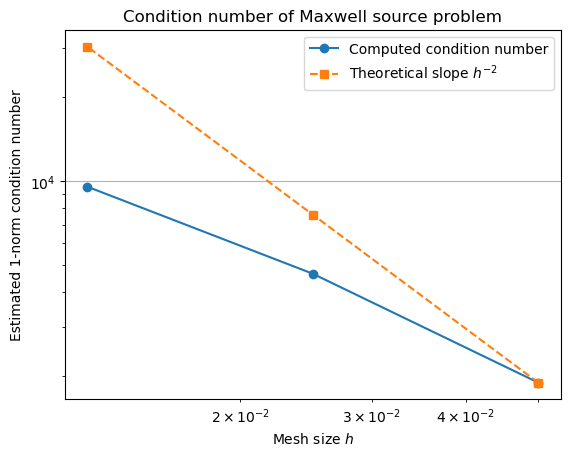

In [26]:
import matplotlib.pyplot as plt

plt.figure()
plt.loglog(hs, conds, "-o", label="Computed condition number")
plt.loglog(hs, conds[0] * (hs / hs[0])**(-2), "--s", label="Theoretical slope $h^{-2}$")
plt.legend()
plt.xlabel("Mesh size $h$")
plt.ylabel("Estimated 1-norm condition number")
plt.title("Condition number of Maxwell source problem")
plt.grid()
plt.show()